# Generated Summary vs Gold Length Analysis

This notebook keeps only the core length-bias analysis:

1. Compare overall average summary length across Gold, mBART, Aya-Expanse, Gemma, and QWEN.
2. Compare model lengths on the same overlapping samples.
3. Report compact length-bias statistics: mean difference, median difference, mean sample ratio, ratio of means, MAE, RMSE, and the percentage of samples longer than gold.

In [1]:
from pathlib import Path
import json
import os
import re
import unicodedata

import pandas as pd

## Paths and Model Setup

In [2]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "outputs").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "length_analysis"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Keep plotting/font caches inside the project tree for portable notebook execution.
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / "matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(OUTPUT_DIR / "xdg_cache"))

DIRECT_PATH = PROJECT_ROOT / "outputs/direct/all_models/direct_all_models_100samples_seed42_results.json"
MBART_PATH = PROJECT_ROOT / "outputs/mbart_baseline/mbart_large50_100samples_seed42_results.json"

MODEL_NAME_MAP = {
    "jjnhuang/mbart-large-50-en-dialogue-to-zh-summary": "mBART",
    "qwen3.5:9b": "QWEN",
    "gemma4:e4b": "Gemma",
    "aya-expanse:8b": "Aya-Expanse",
}

MODEL_ORDER = ["Gold / Reference", "mBART", "Aya-Expanse", "Gemma", "QWEN"]
GEN_MODEL_ORDER = [m for m in MODEL_ORDER if m != "Gold / Reference"]

print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)

Project root: /Users/yunu919/Desktop/grounded-semantic-pipeline
Output dir: /Users/yunu919/Desktop/grounded-semantic-pipeline/outputs/length_analysis


## Load Records

In [3]:
def load_json_records(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open(encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, list):
        return data
    if isinstance(data, dict):
        for value in data.values():
            if isinstance(value, list) and all(isinstance(item, dict) for item in value):
                return value
        return [data]
    raise TypeError(f"Unsupported JSON structure in {path}")


direct_records = load_json_records(DIRECT_PATH)
mbart_records = load_json_records(MBART_PATH)

print("Direct rows:", len(direct_records))
print("mBART rows:", len(mbart_records))

Direct rows: 300
mBART rows: 100


## Token Length

`gold_tokens` is computed from `reference_summary_zh`. Generated lengths are computed from `generated_summary_zh` with the same tokenizer.

In [4]:
try:
    import jieba
    TOKENIZER_NAME = "jieba.lcut"
except ModuleNotFoundError:
    jieba = None
    TOKENIZER_NAME = "regex fallback: CJK char / Latin span / number span / placeholder"


TOKEN_RE = re.compile(r"<[^>\s]+>|[A-Za-z]+(?:[-'][A-Za-z]+)*|\d+(?:\.\d+)?|[\u3400-\u9fff]|[^\s]")


def is_countable_token(token: str) -> bool:
    token = str(token).strip()
    if not token:
        return False
    return any(not unicodedata.category(ch).startswith(("P", "S", "Z")) for ch in token)


def tokenize_summary(text: str) -> list[str]:
    text = str(text or "").strip()
    if not text:
        return []
    raw_tokens = jieba.lcut(text) if jieba is not None else TOKEN_RE.findall(text)
    return [tok.strip() for tok in raw_tokens if is_countable_token(tok)]


def token_length(text: str) -> int:
    return len(tokenize_summary(text))


print("Tokenizer:", TOKENIZER_NAME)
print("Example:", tokenize_summary("佩顿给麦克斯提供了卖衣服的网站。"))

/Applications/anaconda3/envs/nlp/lib/python3.11/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...


Tokenizer: jieba.lcut


Dumping model to file cache /var/folders/wv/6g0vndhj1918ng7mb558jqbh0000gn/T/jieba.cache
Loading model cost 0.247 seconds.
Prefix dict has been built successfully.


Example: ['佩顿', '给', '麦克斯', '提供', '了', '卖', '衣服', '的', '网站']


## Build Length Table

In [5]:
def normalize_record(record: dict, source_file: str, source_group: str) -> dict:
    raw_model_name = record.get("model_name", "")
    model = MODEL_NAME_MAP.get(raw_model_name, raw_model_name)
    generated = str(record.get("generated_summary_zh", "") or "").strip()
    gold = str(record.get("reference_summary_zh", "") or "").strip()
    generated_tokens = token_length(generated)
    gold_tokens = token_length(gold)
    return {
        "model": model,
        "raw_model_name": raw_model_name,
        "sample_index": record.get("sample_index"),
        "generated_summary_zh": generated,
        "reference_summary_zh": gold,
        "generated_tokens": generated_tokens,
        "gold_tokens": gold_tokens,
        "token_diff": generated_tokens - gold_tokens,
        "token_ratio": generated_tokens / gold_tokens if gold_tokens else pd.NA,
        "source_file": source_file,
        "source_group": source_group,
    }


rows = [normalize_record(r, DIRECT_PATH.name, "direct") for r in direct_records]
rows += [normalize_record(r, MBART_PATH.name, "mbart_baseline") for r in mbart_records]
length_df = pd.DataFrame(rows)
length_df["sample_index"] = pd.to_numeric(length_df["sample_index"], errors="coerce").astype("Int64")

display(length_df.head())
display(length_df["model"].value_counts().reindex(GEN_MODEL_ORDER))

,model,raw_model_name,sample_index,generated_summary_zh,reference_summary_zh,generated_tokens,gold_tokens,token_diff,token_ratio,source_file,source_group
0,Aya-Expanse,aya-expanse:8b,0,麦克斯问派顿是否知道哪里可以买到好衣服。派顿列出了几个网站，但表示通常会从两个或三个网站购买...,佩顿给麦克斯提供了卖衣服的网站。他喜欢浏览、试穿衣服，但不一定都会买。他经常买衣服和书，因为...,94,31,63,3.032258,direct_all_models_100samples_seed42_results.json,direct
1,Aya-Expanse,aya-expanse:8b,1,奥利、凯利、米奇和杰西卡在聊天，分享他们认为最可怕或最令人印象深刻的地方。凯利提到芬兰的一个...,凯利很害怕芬兰雕塑花园里的人物，因为她觉得那些人物的脸非常病态。对奥利来说，这就像日本的人偶...,80,29,51,2.758621,direct_all_models_100samples_seed42_results.json,direct
2,Aya-Expanse,aya-expanse:8b,2,埃里克问贝拉今天老板房间里发生了什么，老板是否生气。贝拉回答说老板并没有生气，反而对他们拒绝...,贝拉和埃里克拒绝了一个客户的要求。他们老板很赞赏这个决定。他会吸引新的客户来。,52,21,31,2.476190,direct_all_models_100samples_seed42_results.json,direct
3,Aya-Expanse,aya-expanse:8b,3,玛丽：嘿，我有点缺钱，能借我几百元吗？\n卡特：好的，给我一个小时，我在火车站。\n玛丽：行...,玛丽的钱用完了，卡特打算一小时后借给她一点。,23,14,9,1.642857,direct_all_models_100samples_seed42_results.json,direct
4,Aya-Expanse,aya-expanse:8b,4,杰克提议后来喝鸡尾酒，梅激动地回应“是！”她表示自己确实很紧张。杰克猜测了，梅叹了口气，承认...,杰克和梅一会儿要喝鸡尾酒。,37,7,30,5.285714,direct_all_models_100samples_seed42_results.json,direct


model
mBART          100
Aya-Expanse    100
Gemma          100
QWEN           100
Name: count, dtype: int64

In [6]:
# Basic data-shape checks.
assert len(direct_records) == 300, f"Expected 300 direct rows, found {len(direct_records)}"
assert len(mbart_records) == 100, f"Expected 100 mBART rows, found {len(mbart_records)}"

samples_by_model = length_df.groupby("model")["sample_index"].apply(lambda s: set(s.dropna()))
expected_samples = set(range(100))
for model in GEN_MODEL_ORDER:
    assert samples_by_model[model] == expected_samples, f"Sample-index mismatch for {model}"

print("Validation passed: all generated models cover the same 100 samples.")

Validation passed: all generated models cover the same 100 samples.


## 1. Overall Average Length by Model

This table compares the average generated length for each model against the average gold/reference length.

In [7]:
gold_by_sample_df = (
    length_df[["sample_index", "reference_summary_zh", "gold_tokens"]]
    .drop_duplicates("sample_index")
    .sort_values("sample_index")
    .reset_index(drop=True)
)

gold_row = {
    "Model": "Gold / Reference",
    "Average length": gold_by_sample_df["gold_tokens"].mean(),
    "n": gold_by_sample_df["gold_tokens"].count(),
    "std": gold_by_sample_df["gold_tokens"].std(ddof=1),
    "median": gold_by_sample_df["gold_tokens"].median(),
    "min": gold_by_sample_df["gold_tokens"].min(),
    "max": gold_by_sample_df["gold_tokens"].max(),
}

model_average_df = (
    length_df.groupby("model", as_index=False)
    .agg(
        **{
            "Model": ("model", "first"),
            "Average length": ("generated_tokens", "mean"),
            "n": ("sample_index", "count"),
            "std": ("generated_tokens", "std"),
            "median": ("generated_tokens", "median"),
            "min": ("generated_tokens", "min"),
            "max": ("generated_tokens", "max"),
        }
    )
    [["Model", "Average length", "n", "std", "median", "min", "max"]]
)

overall_length_df = pd.concat([pd.DataFrame([gold_row]), model_average_df], ignore_index=True)
overall_length_df["Model"] = pd.Categorical(overall_length_df["Model"], categories=MODEL_ORDER, ordered=True)
overall_length_df = overall_length_df.sort_values("Model").reset_index(drop=True)

display(overall_length_df.round(2))

,Model,Average length,n,std,median,min,max
0,Gold / Reference,17.21,100,9.17,16.0,3,46
1,mBART,15.04,100,10.69,12.0,3,79
2,Aya-Expanse,49.15,100,23.17,45.5,12,135
3,Gemma,35.93,100,18.72,34.0,7,91
4,QWEN,41.23,100,18.67,37.5,12,94


## Recommended Length-Bias Statistics

For length bias, average length alone is not enough. The most useful compact statistics are:

- `mean_diff`: average generated length minus gold length.
- `median_diff`: robust central tendency of the paired difference.
- `ratio_of_means`: total generated tokens divided by total gold tokens.
- `mean_sample_ratio`: average of each sample's generated/gold ratio.
- `pct_longer_than_gold`: percentage of samples where the model is longer than gold.
- `pct_within_25pct`: percentage of samples within ±25% of gold length.
- `mae_diff` and `rmse_diff`: absolute magnitude of length mismatch.

In [8]:
def rmse(series: pd.Series) -> float:
    return (series.pow(2).mean()) ** 0.5


length_bias_df = (
    length_df.groupby("model")
    .agg(
        n=("sample_index", "count"),
        avg_generated_tokens=("generated_tokens", "mean"),
        avg_gold_tokens=("gold_tokens", "mean"),
        mean_diff=("token_diff", "mean"),
        median_diff=("token_diff", "median"),
        mae_diff=("token_diff", lambda s: s.abs().mean()),
        rmse_diff=("token_diff", rmse),
        mean_sample_ratio=("token_ratio", "mean"),
        pct_longer_than_gold=("token_diff", lambda s: (s > 0).mean() * 100),
        pct_shorter_than_gold=("token_diff", lambda s: (s < 0).mean() * 100),
        pct_within_25pct=("token_ratio", lambda s: ((s >= 0.75) & (s <= 1.25)).mean() * 100),
    )
    .reset_index()
)
length_bias_df["ratio_of_means"] = length_bias_df["avg_generated_tokens"] / length_bias_df["avg_gold_tokens"]
length_bias_df["model"] = pd.Categorical(length_bias_df["model"], categories=GEN_MODEL_ORDER, ordered=True)
length_bias_df = length_bias_df.sort_values("model").reset_index(drop=True)

display(length_bias_df.round(2))

,model,n,avg_generated_tokens,avg_gold_tokens,mean_diff,median_diff,mae_diff,rmse_diff,mean_sample_ratio,pct_longer_than_gold,pct_shorter_than_gold,pct_within_25pct,ratio_of_means
0,mBART,100,15.04,17.21,-2.17,-3.0,7.69,11.64,1.02,28.0,64.0,42.0,0.87
1,Aya-Expanse,100,49.15,17.21,31.94,29.0,31.94,37.79,3.36,99.0,0.0,4.0,2.86
2,Gemma,100,35.93,17.21,18.72,17.0,19.54,24.43,2.38,89.0,8.0,15.0,2.09
3,QWEN,100,41.23,17.21,24.02,21.0,24.04,28.73,2.83,98.0,1.0,5.0,2.40


## 2. Paired Length Comparison on the Same Samples

Each row is one shared sample. This is the cleanest setup for comparing model length bias because every model is evaluated against the same gold/reference summary.

In [9]:
generated_wide_df = length_df.pivot_table(
    index="sample_index",
    columns="model",
    values="generated_tokens",
    aggfunc="first",
).reset_index()

paired_length_df = generated_wide_df.merge(
    gold_by_sample_df[["sample_index", "gold_tokens"]],
    on="sample_index",
    how="left",
)

paired_length_df = paired_length_df[["sample_index", "gold_tokens", *GEN_MODEL_ORDER]]

for model in GEN_MODEL_ORDER:
    paired_length_df[f"{model}_diff"] = paired_length_df[model] - paired_length_df["gold_tokens"]
    paired_length_df[f"{model}_ratio"] = paired_length_df[model] / paired_length_df["gold_tokens"].replace(0, pd.NA)

display(paired_length_df.head(20))

,sample_index,gold_tokens,mBART,Aya-Expanse,Gemma,QWEN,mBART_diff,mBART_ratio,Aya-Expanse_diff,Aya-Expanse_ratio,Gemma_diff,Gemma_ratio,QWEN_diff,QWEN_ratio
0,0,31,8,94,46,62,-23,0.258065,63,3.032258,15,1.483871,31,2.000000
1,1,29,9,80,84,59,-20,0.310345,51,2.758621,55,2.896552,30,2.034483
2,2,21,9,52,50,30,-12,0.428571,31,2.476190,29,2.380952,9,1.428571
3,3,14,9,23,12,17,-5,0.642857,9,1.642857,-2,0.857143,3,1.214286
4,4,7,8,37,40,39,1,1.142857,30,5.285714,33,5.714286,32,5.571429
5,5,16,79,61,33,33,63,4.937500,45,3.812500,17,2.062500,17,2.062500
6,6,42,6,92,74,82,-36,0.142857,50,2.190476,32,1.761905,40,1.952381
7,7,9,9,26,35,36,0,1.000000,17,2.888889,26,3.888889,27,4.000000
8,8,17,15,62,30,20,-2,0.882353,45,3.647059,13,1.764706,3,1.176471
9,9,7,7,34,15,27,0,1.000000,27,4.857143,8,2.142857,20,3.857143


## Plots

In [10]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

colors = {
    "Gold / Reference": "#444444",
    "mBART": "#4C78A8",
    "Aya-Expanse": "#F58518",
    "Gemma": "#54A24B",
    "QWEN": "#B279A2",
}

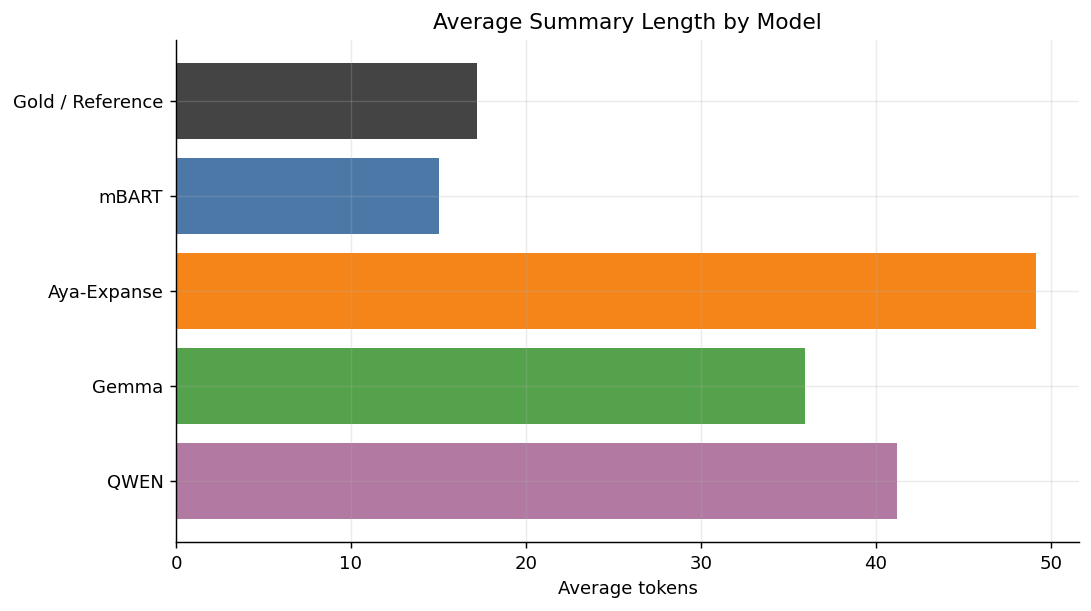

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_df = overall_length_df.copy()
ax.barh(
    plot_df["Model"].astype(str),
    plot_df["Average length"],
    color=[colors.get(str(model), "#999999") for model in plot_df["Model"]],
)
ax.set_title("Average Summary Length by Model")
ax.set_xlabel("Average tokens")
ax.set_ylabel("")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "average_length_by_model.png", bbox_inches="tight")
plt.show()

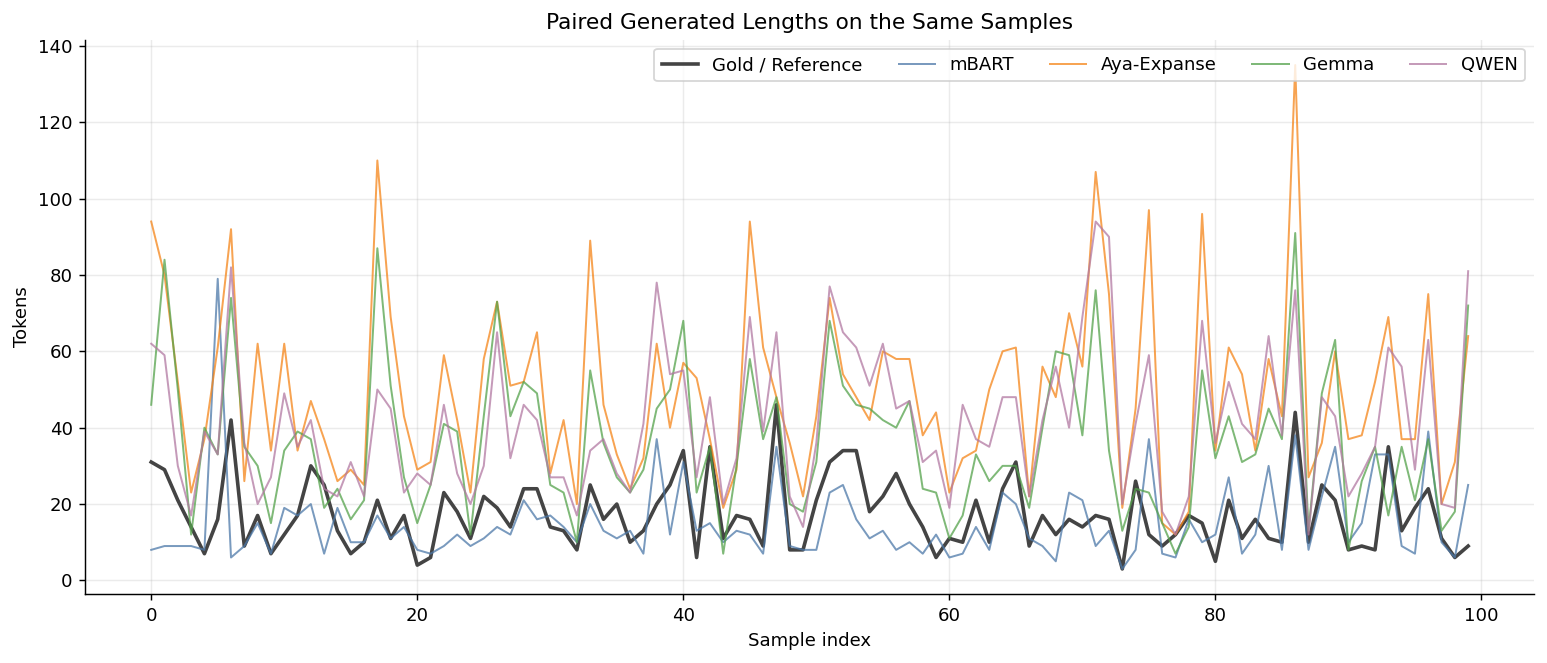

In [12]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(
    paired_length_df["sample_index"],
    paired_length_df["gold_tokens"],
    label="Gold / Reference",
    color=colors["Gold / Reference"],
    linewidth=2.0,
)
for model in GEN_MODEL_ORDER:
    ax.plot(
        paired_length_df["sample_index"],
        paired_length_df[model],
        label=model,
        color=colors[model],
        alpha=0.75,
        linewidth=1.1,
    )
ax.set_title("Paired Generated Lengths on the Same Samples")
ax.set_xlabel("Sample index")
ax.set_ylabel("Tokens")
ax.legend(ncol=5, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "paired_sample_lengths.png", bbox_inches="tight")
plt.show()

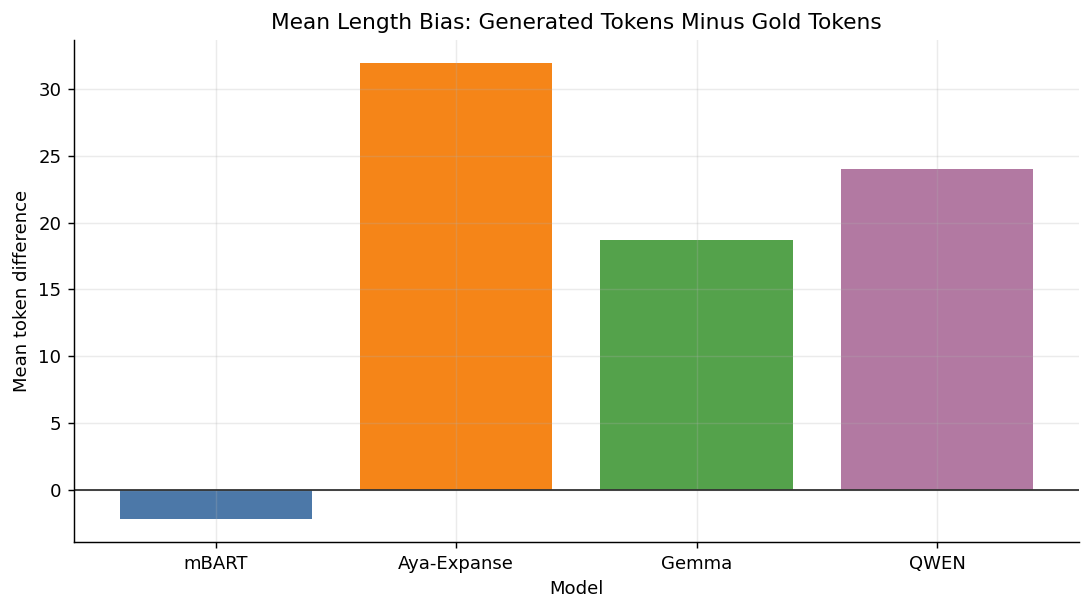

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bias_plot_df = length_bias_df.copy()
ax.bar(
    bias_plot_df["model"].astype(str),
    bias_plot_df["mean_diff"],
    color=[colors.get(str(model), "#999999") for model in bias_plot_df["model"]],
)
ax.axhline(0, color="#333333", linewidth=1)
ax.set_title("Mean Length Bias: Generated Tokens Minus Gold Tokens")
ax.set_xlabel("Model")
ax.set_ylabel("Mean token difference")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mean_length_bias_by_model.png", bbox_inches="tight")
plt.show()

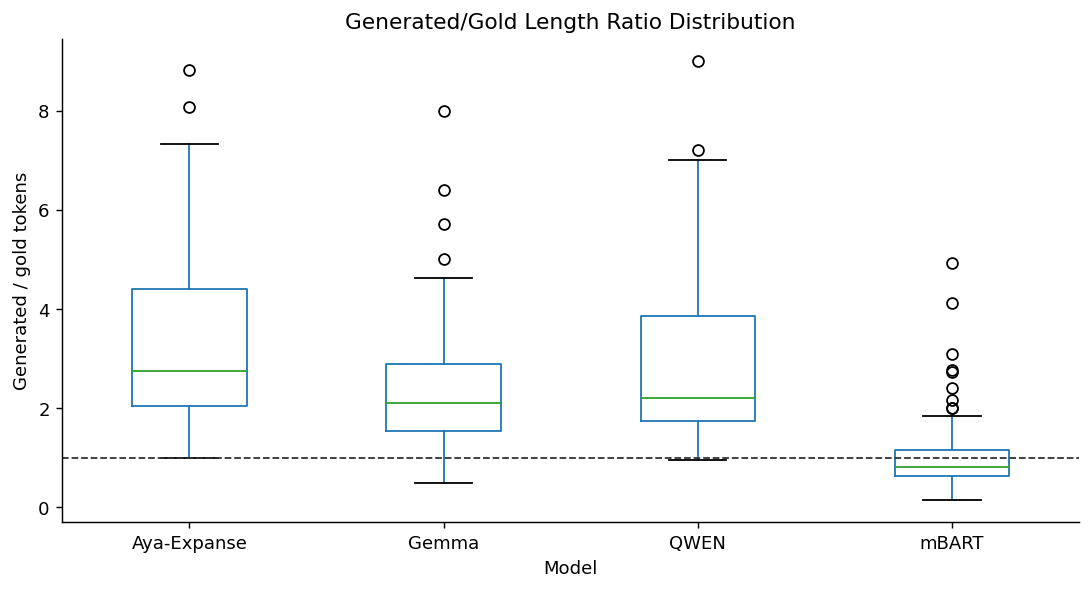

In [14]:
ratio_cols = [f"{model}_ratio" for model in GEN_MODEL_ORDER]
ratio_plot_df = paired_length_df[["sample_index", *ratio_cols]].melt(
    id_vars="sample_index",
    var_name="model",
    value_name="generated_gold_ratio",
)
ratio_plot_df["model"] = ratio_plot_df["model"].str.replace("_ratio", "", regex=False)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ratio_plot_df.boxplot(column="generated_gold_ratio", by="model", ax=ax, grid=False)
ax.axhline(1.0, color="#333333", linestyle="--", linewidth=1)
ax.set_title("Generated/Gold Length Ratio Distribution")
ax.set_xlabel("Model")
ax.set_ylabel("Generated / gold tokens")
fig.suptitle("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "length_ratio_distribution_by_model.png", bbox_inches="tight")
plt.show()

## Save Core Outputs

In [15]:
# Compatibility outputs used by downstream notebooks.
model_gold_length_comparison_df = length_bias_df.rename(columns={"model": "model"})[
    [
        "model",
        "n",
        "avg_generated_tokens",
        "avg_gold_tokens",
        "mean_diff",
        "median_diff",
        "mean_sample_ratio",
        "ratio_of_means",
        "mae_diff",
        "rmse_diff",
        "pct_longer_than_gold",
        "pct_within_25pct",
    ]
]

report_generated_vs_gold_df = overall_length_df.rename(
    columns={"Average length": "Generated summary length"}
)

direct_300_comparison_df = length_df[length_df["source_group"] == "direct"].sort_values(["sample_index", "model"])
all_model_comparison_df = length_df.sort_values(["sample_index", "model"])
gold_length_by_sample_wide_df = paired_length_df[["sample_index", "gold_tokens", *GEN_MODEL_ORDER]]

model_gold_length_comparison_df.to_csv(OUTPUT_DIR / "model_gold_length_comparison.csv", index=False, encoding="utf-8-sig")
report_generated_vs_gold_df.to_csv(OUTPUT_DIR / "report_generated_vs_gold_length.csv", index=False, encoding="utf-8-sig")
direct_300_comparison_df.to_csv(OUTPUT_DIR / "direct_300_gold_length_comparison.csv", index=False, encoding="utf-8-sig")
all_model_comparison_df.to_csv(OUTPUT_DIR / "all_models_gold_length_comparison_400rows.csv", index=False, encoding="utf-8-sig")
gold_length_by_sample_wide_df.to_csv(OUTPUT_DIR / "gold_length_by_sample_wide.csv", index=False, encoding="utf-8-sig")

# Extra core outputs with clearer names.
overall_length_df.to_csv(OUTPUT_DIR / "overall_average_length_by_model.csv", index=False, encoding="utf-8-sig")
length_bias_df.to_csv(OUTPUT_DIR / "length_bias_statistics_by_model.csv", index=False, encoding="utf-8-sig")
paired_length_df.to_csv(OUTPUT_DIR / "paired_sample_length_comparison.csv", index=False, encoding="utf-8-sig")

print("Saved CSV outputs to", OUTPUT_DIR)
print("Saved figures to", FIGURE_DIR)

Saved CSV outputs to /Users/yunu919/Desktop/grounded-semantic-pipeline/outputs/length_analysis
Saved figures to /Users/yunu919/Desktop/grounded-semantic-pipeline/outputs/length_analysis/figures
